# Import Library

In [3]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None # Menonaktifkan peringatan chaining

import numpy as np # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed) # Mengatur seed untuk reproduktibilitas

import matplotlib.pyplot as plt # Matplotlib untuk visualisasi data

import seaborn as sns # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt # Manipulasi data waktu dan tanggal
import re # Modul untuk bekerja dengan ekspresi reguler
import string # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize # Tokenisasi teks
from nltk.corpus import stopwords # Daftar kata-kata berhenti dalam teks

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt') # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords') # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Thinkpad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Thinkpad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Scraping Dataset

In [4]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi dengan ID 'com.byu.id' di Google Play Store.
# Proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada.
scrapreview = reviews_all(
  'com.byu.id',     # ID aplikasi
  lang='id',       # Bahasa ulasan (default: 'en')
  country='id',     # Negara (default: 'us')
  sort=Sort.MOST_RELEVANT, # Urutan ulasan (default: Sort.MOST_RELEVANT)
  count=1000       # Jumlah maksimum ulasan yang ingin diambil
)

# Menyimpan Ulasan

In [5]:
# Menyimpan ulasan dalam file CSV
import csv

with open('ulasan_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
  writer = csv.writer(file)
  writer.writerow(['Review']) # Menulis header kolom
  for review in scrapreview:
    writer.writerow([review['content']]) # Menulis konten ulasan ke dalam file CSV

# Loading Dataset

In [6]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('ulasan_aplikasi.csv', index=False)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview)

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [7]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,73d828a2-4091-4c85-99be-622ee23ebfd9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya pengguna lama dan setia by.U, awalnya say...",1,92,1.64.1-prod-byu,2026-02-19 23:06:58,"Halo, Kak. Maafin yaa jadi gak nyaman karena k...",2026-02-19 23:10:10,1.64.1-prod-byu
1,58f237aa-4b5d-4315-9650-6f348f715234,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Gw pengguna by.u dari lama, awal awal muncul. ...",1,1499,1.64.1-prod-byu,2026-01-19 18:31:39,"Hi Kak Fajar, maaf belum bisa bikin kamu nyama...",2026-01-19 18:36:14,1.64.1-prod-byu
2,04b81bd9-9b0b-4d0f-b334-f8ab9f2300ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aku pengguna dari 2020, waktu itu by.u hargany...",4,76,1.64.1-prod-byu,2026-01-26 21:07:25,"Hai Kak, makasih ya udah kasih tanggapan. Harg...",2026-01-26 23:31:53,1.64.1-prod-byu
3,78cfd763-5f7d-4ab8-8d51-4def876b65fd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya pengguna Byu dari awal rilis, Awalnya ena...",1,153,1.64.1-prod-byu,2026-01-25 14:43:14,"Hai Kak, maaf udah bikin ga nyaman ya :( Buat ...",2026-01-25 16:38:39,1.64.1-prod-byu
4,7756ea57-6add-4ef0-8759-fbbafff669dd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi parah.. di buka aja Ndak bisa.. udah ...,1,10,1.64.1-prod-byu,2026-02-21 08:15:34,"Hai Kak, maaf udah bikin ga nyaman ya :( unjtu...",2026-02-21 08:17:40,1.64.1-prod-byu


In [8]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              108000 non-null  str           
 1   userName              108000 non-null  str           
 2   userImage             108000 non-null  str           
 3   content               108000 non-null  str           
 4   score                 108000 non-null  int64         
 5   thumbsUpCount         108000 non-null  int64         
 6   reviewCreatedVersion  87242 non-null   str           
 7   at                    108000 non-null  datetime64[us]
 8   replyContent          102580 non-null  str           
 9   repliedAt             102580 non-null  datetime64[us]
 10  appVersion            87242 non-null   str           
dtypes: datetime64[us](2), int64(2), str(7)
memory usage: 67.1 MB


In [9]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [10]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [11]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 82616 entries, 0 to 107999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              82616 non-null  str           
 1   userName              82616 non-null  str           
 2   userImage             82616 non-null  str           
 3   content               82616 non-null  str           
 4   score                 82616 non-null  int64         
 5   thumbsUpCount         82616 non-null  int64         
 6   reviewCreatedVersion  82616 non-null  str           
 7   at                    82616 non-null  datetime64[us]
 8   replyContent          82616 non-null  str           
 9   repliedAt             82616 non-null  datetime64[us]
 10  appVersion            82616 non-null  str           
dtypes: datetime64[us](2), int64(2), str(7)
memory usage: 53.1 MB


# Preprocessing Text

1. cleaningText(text): Membersihkan teks dengan menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, karakter newline diganti dengan spasi dan spasi ekstra pada awal dan akhir teks dihapus
2. casefoldingText(text): Mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase) untuk membuat teks menjadi seragam.
3. tokenizingText(text): Memecah teks menjadi daftar kata atau token. Ini membantu dalam mengurai teks menjadi komponen-komponen dasar untuk analisis lebih lanjut.
4. filteringText(text): Menghapus kata-kata berhenti (stopwords) dalam teks. Daftar kata-kata berhenti telah diperbarui dengan beberapa kata tambahan
5. stemmingText(text): Menerapkan stemming pada teks, yakni mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.
6. toSentence(list_words): Menggabungkan daftar kata-kata menjadi sebuah kalimat.

In [37]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
  text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
  text = re.sub(r'RT[\s]', '', text) # menghapus RT
  text = re.sub(r"http\S+", '', text) # menghapus link
  text = re.sub(r'[0-9]+', '', text) # menghapus angka
  text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

  text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
  text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
  text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
  return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
  text = text.lower()
  return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
  text = word_tokenize(text)
  return text

def filteringText(text): # Menghapus stopwords dalam teks
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy","yg","udh","kalo", "aja", "udah"])
  filtered = []
  for txt in text:
    if txt not in listStopwords:
      filtered.append(txt)
  text = filtered
  return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
  # Membuat objek stemmer
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  # Memecah teks menjadi daftar kata
  words = text.split()

  # Menerapkan stemming pada setiap kata dalam daftar
  stemmed_words = [stemmer.stem(word) for word in words]

  # Menggabungkan kata-kata yang telah distem
  stemmed_text = ' '.join(stemmed_words)

  return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
  sentence = ' '.join(word for word in list_words)
  return sentence

menghapus slangword

In [38]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "kalo": "kalau", "gk": "gak", "gak": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak", "sbg": "sebagai", "sbgi": "sebagai", "sbgnya": "sebagainya", "sbgmna": "sebagaimana", "sbgmn": "sebagaimana", "sbgmna": "sebagaimana", "sbgmnnya": "sebagaimananya", "sbgmnynya": "sebagaimananya", "sbgmnynya": "sebagaimananya", "sbgmna": "sebagaimana", "sbgmna saja": "sebagaimana saja", "udh": "sudah", "udh": "sudah", "udh": "sudah"}
def fix_slangwords(text):
  words = text.split()
  fixed_words = []

  for word in words:
    if word.lower() in slangwords:
      fixed_words.append(slangwords[word.lower()])
    else:
      fixed_words.append(word)

  fixed_text = ' '.join(fixed_words)
  return fixed_text

menerapkan preprocessing

In [39]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

# Pelabelan

In [40]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
  # Jika permintaan berhasil
  reader = csv.reader(StringIO(response.text), delimiter=',')
  # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

  for row in reader:
    # Mengulangi setiap baris dalam file CSV
    lexicon_positive[row[0]] = int(row[1])
    # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
  print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
  # Jika permintaan berhasil
  reader = csv.reader(StringIO(response.text), delimiter=',')
  # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

  for row in reader:
    # Mengulangi setiap baris dalam file CSV
    lexicon_negative[row[0]] = int(row[1])
    # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
  print("Failed to fetch negative lexicon data")

In [41]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
  #for word in text:

  score = 0
  # Inisialisasi skor sentimen ke 0

  for word in text:
    # Mengulangi setiap kata dalam teks

    if (word in lexicon_positive):
      score = score + lexicon_positive[word]
      # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

  for word in text:
    # Mengulangi setiap kata dalam teks (sekali lagi)

    if (word in lexicon_negative):
      score = score + lexicon_negative[word]
      # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

  polarity=''
  # Inisialisasi variabel polaritas

  if (score >= 0):
    polarity = 'positive'
    # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
  elif (score < 0):
    polarity = 'negative'
    # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

  # else:
  #     polarity = 'neutral'
  # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

  return score, polarity
  # Mengembalikan skor sentimen dan polaritas teks

In [42]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    48395
positive    34221
Name: count, dtype: int64


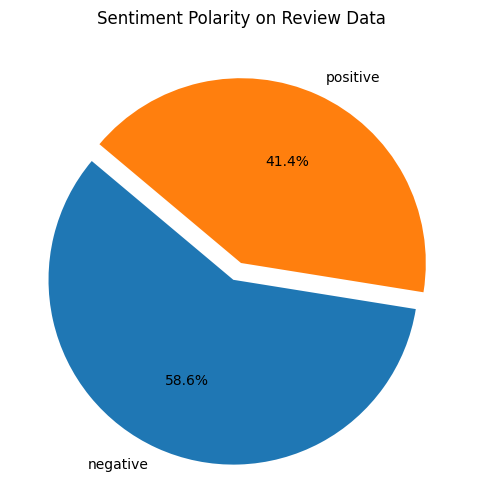

In [43]:
import matplotlib.pyplot as plt

# 1. Ambil data jumlah labelnya
counts = clean_df['polarity'].value_counts()

# 2. Setup warna (biar mirip: biru untuk negatif, orange untuk positif)
colors = ['#1f77b4', '#ff7f0e']

# 3. Plotting
plt.figure(figsize=(6, 6))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%',      # Menampilkan persentase
    startangle=140,         # Memutar sudut awal biar posisinya pas
    colors=colors,
    explode=(0.1, 0)        # Memberikan efek 'potongan' keluar pada label pertama
)

plt.title('Sentiment Polarity on Review Data')
plt.show()

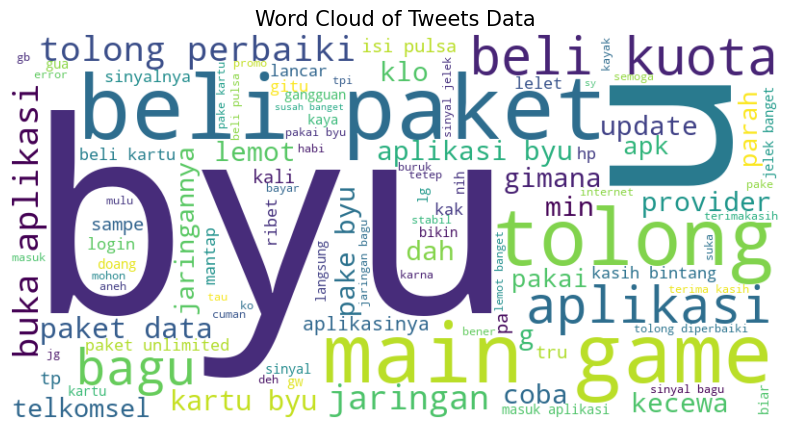

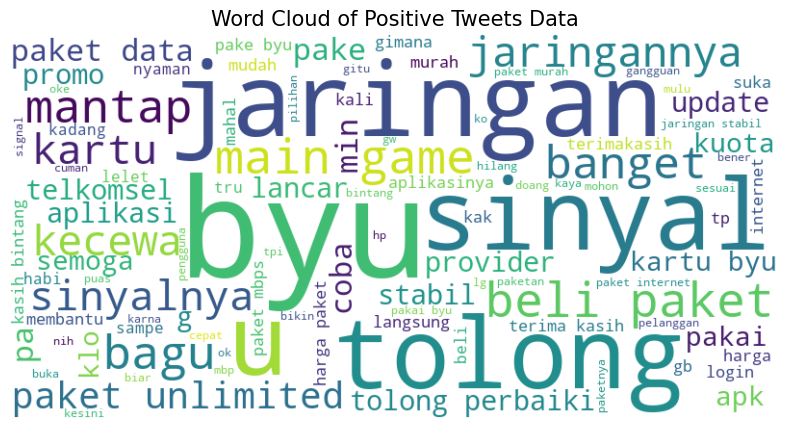

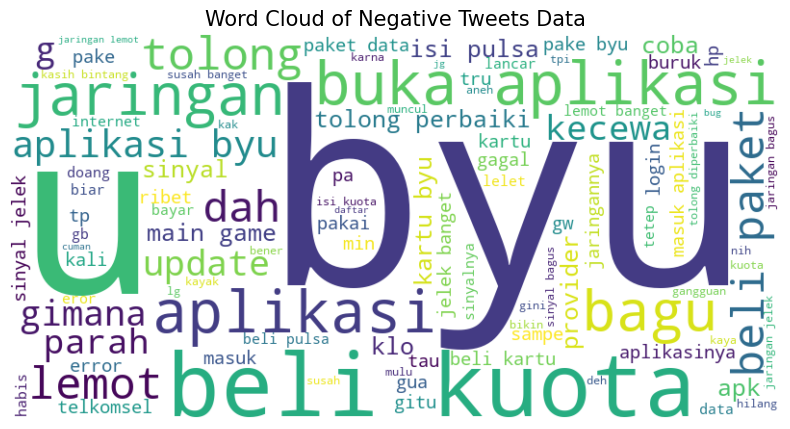

In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fungsi biar nggak ngetik berulang-ulang
def generate_wordcloud(data, title):
    # Gabungin semua baris teks jadi satu string raksasa
    all_text = ' '.join([' '.join(map(str, x)) if isinstance(x, list) else str(x) for x in data])
    all_text = all_text.replace("'", "").replace("[", "").replace("]", "").replace(",", "")
    
    # Setting tampilan WordCloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        colormap='viridis', # Warna bisa diganti (misal: 'magma' atau 'plasma')
        max_words=100
    ).generate(all_text)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=15)
    plt.axis('off') # Sembunyikan sumbu x dan y
    plt.show()

# --- EKSEKUSI ---

# 1. WordCloud General (Semua Data)
generate_wordcloud(clean_df['text_stopword'], 'Word Cloud of Tweets Data')

# 2. WordCloud Positive Only
pos_data = clean_df[clean_df['polarity'] == 'positive']['text_stopword']
generate_wordcloud(pos_data, 'Word Cloud of Positive Tweets Data')

# 3. WordCloud Negative Only
neg_data = clean_df[clean_df['polarity'] == 'negative']['text_stopword']
generate_wordcloud(neg_data, 'Word Cloud of Negative Tweets Data')

# Ekstraksi Fitur

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Modeling

### Naive Bayes

In [47]:
from sklearn.naive_bayes import BernoulliNB

# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7998244870786176
Naive Bayes - accuracy_test: 0.796235778261922


### Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9736428009441385
Random Forest - accuracy_test: 0.8448317598644396


### Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8722689584215941
Logistic Regression - accuracy_test: 0.8684943113047688


In [52]:
from sklearn.tree import DecisionTreeClassifier

# Membuat objek model Decision Tree
decision_tree = DecisionTreeClassifier()

# Melatih model Decision Tree pada data pelatihan
decision_tree.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

# Evaluasi akurasi model Decision Tree
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9736428009441385
Decision Tree - accuracy_test: 0.7960542241587993
